# Notebook 1: Front Detection Using the Half-Power Point Method

**Kinetic Energy Trends and Eddy Saturation in the Southern Ocean**  
Cristina Martí-Solana, Simón Ruiz, Bàrbara Barceló-Llull, Vincent Combes and Ananda Pascual  
Contact: cmarti@imedea.uib-csic.es

---

This notebook implements the **Chambers et al. (2018) half-power point method** for detecting frontal positions in the Southern Ocean using gridded altimetry data.

> **Prerequisite:** Run **Notebook 0** (`00_preprocessing.ipynb`) first to compute the
> permanent ice mask, long-term mean velocities, and mean ADT. Those outputs are
> loaded from `outputs/preprocessing.nc` at the start of this notebook.

The method works as follows:
1. **Load preprocessed data** — permanent ice mask and long-term mean velocities from Notebook 0
2. Compute **Mean Kinetic Energy (KE)** and **Eddy Kinetic Energy (EKE)** for each month:
   - $\text{KE} = \frac{1}{2}\!\left(\bar{u}_{month}^{2} + \bar{v}_{month}^{2}\right)$ — from monthly-mean absolute geostrophic velocities
   - $\text{EKE} = \frac{1}{2}\,\overline{\!\left(u - \bar{u}_{lt}\right)^{2} + \left(v - \bar{v}_{lt}\right)^{2}}$ — mean of squared anomalies from the **full-period** mean, averaged over the monthly daily snapshots
   - **Note:** anomalies $u' = u_{gos} - \bar{u}_{lt}$ use the study-period mean as reference (rather than CMEMS's `ugosa`/`vgosa`, whose reference period differs, or a within-month mean which aliases seasonal variability into EKE).
3. For each meridional profile across the Southern Ocean, identify **contiguous segments** where EKE exceeds a threshold (0.02 m²/s²)
4. Within each segment, find the **peak EKE** and define an envelope bounded by the 25% peak fraction
5. Compute the **half-power point** — the latitude where half the cumulative EKE within the envelope is reached — as the energy-weighted frontal position

### Data Products Used
| Product ID | Description |
|---|---|
| SEALEVEL_GLO_PHY_L4_MY_008_047 (all-sat)| Gridded L4 altimetry (0.125° resolution, daily) |
| SEALEVEL_GLO_PHY_L4_MY_008_057 (two-sat)| Gridded L4 altimetry (0.125° resolution, daily) |

## 1. Setup and Imports

In [1]:
import os
import glob
import sys
import importlib
import xarray as xr
import matplotlib.pyplot as plt
import numpy as np
import cartopy.crs as ccrs
from cartopy import feature as cfeature

# ── Copernicus Marine Toolbox (optional, required for remote access) ──
try:
    import copernicusmarine
    _CMEMS_AVAILABLE = True
except ImportError:
    _CMEMS_AVAILABLE = False
    print("WARNING: copernicusmarine not installed — remote access unavailable.")
    print("         Install with:  pip install copernicusmarine")

# Authenticate once — credentials are cached for the rest of the session.
if _CMEMS_AVAILABLE:
    copernicusmarine.login()

# Add the repository's scripts directory to the Python path if not already present
REPO_ROOT = os.path.abspath(os.path.join(os.getcwd(), '..'))
scripts_path = os.path.join(REPO_ROOT, 'scripts')
if scripts_path not in sys.path:
    sys.path.insert(0, scripts_path)

# Force reload utils modules to pick up any recent changes
import utils.regions_and_masks
import utils.chambers_fronts
importlib.reload(utils.regions_and_masks)
importlib.reload(utils.chambers_fronts)

from utils.chambers_fronts import detect_fronts_from_dataset
from utils.regions_and_masks import preprocessing_region, compute_max_ice_mask

print(f"Repository root: {REPO_ROOT}")
print(f"Copernicus Marine Toolbox available: {_CMEMS_AVAILABLE}")
print("Imports OK.")


.venv-1/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
INFO - 2026-07-06T07:16:05Z - Downloading Copernicus Marine data requires a Copernicus Marine username and password, sign up for free at: https://data.marine.copernicus.eu/register


Copernicus Marine username:Copernicus Marine password:File ~/.copernicusmarine/.copernicusmarine-credentials already exists, overwrite it ? [y/N]:

INFO - 2026-07-06T07:16:15Z - Credentials file stored in ~/.copernicusmarine/.copernicusmarine-credentials.


Repository root: repository
Copernicus Marine Toolbox available: True
Imports OK.


## 2. Configuration

Define input/output directories and processing parameters.

In [2]:
# ── Remote data access (Copernicus Marine Toolbox) ──────────────────────────
# Set USE_REMOTE_DATA = True  to stream data directly from CMEMS servers
# without storing files locally.  Requires the copernicusmarine package and a
# valid CMEMS account (free registration: https://data.marine.copernicus.eu/register).
# On first run you will be prompted for credentials; they are cached automatically.
# Set USE_REMOTE_DATA = False to read from a local directory tree (INPUT_DIR).
USE_REMOTE_DATA  = True

# Copernicus Marine dataset ID for the DUACS all-satellite MY L4 product
# (SEALEVEL_GLO_PHY_L4_MY_008_047).  Change to the two-sat ID below if needed:
#   two-sat: "cmems_obs-sl_glo_phy-ssh_my_twosat-l4-duacs-0.125deg_P1D"
DATASET_ID       = "cmems_obs-sl_glo_phy-ssh_my_allsat-l4-duacs-0.125deg_P1D"
REMOTE_VARIABLES = ["ugos", "vgos", "flag_ice", "adt"]

# ── Input data (local fallback, only used when USE_REMOTE_DATA = False) ──────
# Path to CMEMS L4 altimetry data (yearly/monthly folder structure)
INPUT_DIR = "/Volumes/My Book/DUACS MY/all_sat/SEALEVEL_GLO_PHY_L4_MY_008_047/cmems_obs-sl_glo_phy-ssh_my_allsat-l4-duacs-0.125deg_P1D_202411"

# ── Preprocessing outputs (from Notebook 0) ──────────────────────────────────
PREPROC_FILE = os.path.join(REPO_ROOT, "outputs", "preprocessing.nc")

# ── Output directory ──────────────────────────────────────────────────────────
OUTPUT_DIR = os.path.join(REPO_ROOT, "outputs", "monthly_half-power_points")

# ── Processing region (Southern Ocean) ───────────────────────────────────────
LONMIN, LONMAX = -179.9375, 179.9375
LATMIN, LATMAX = -65, -35

# ── Method parameters (Chambers et al. 2018 defaults) ────────────────────────
THRESHOLD    = 0.02        # EKE threshold [m²/s²]
MIN_WIDTH_KM = 300.0       # Minimum envelope width [km]
PEAK_FRACTION = 0.20        # Fraction of peak for envelope boundaries
SAMPLE_EVERY = 1           # Sample every Nth longitude (1 = all)
USE_NUMBA    = True        # Set True if numba is installed for acceleration
N_JOBS       = -1          # Threads for parallel longitude scan (-1 = all CPUs)

# ── Year selection ────────────────────────────────────────────────────────────
# Set to None to process all available years (local mode only), or a list like
# ["2020", "2021"].  When USE_REMOTE_DATA = True this list must be set explicitly.
YEARS_TO_PROCESS = ["2001","2002","2003","2004","2005","2006","2007","2008","2009","2010","2011","2012","2013","2014","2015","2016","2017","2018","2019","2020","2021","2022","2023","2024","2025"]

# ── Validation ────────────────────────────────────────────────────────────────
if USE_REMOTE_DATA and not _CMEMS_AVAILABLE:
    raise ImportError(
        "USE_REMOTE_DATA=True but copernicusmarine is not installed.\n"
        "Run:  pip install copernicusmarine"
    )
if USE_REMOTE_DATA and YEARS_TO_PROCESS is None:
    raise ValueError(
        "Set YEARS_TO_PROCESS explicitly when USE_REMOTE_DATA=True.\n"
        "Example: YEARS_TO_PROCESS = ['2011', '2012', '2013']"
    )
if not os.path.exists(PREPROC_FILE):
    raise FileNotFoundError(
        f"Preprocessing file not found: {PREPROC_FILE}\n"
        "Run Notebook 0 (00_preprocessing.ipynb) first."
    )

print("Configuration loaded.")
print(f"Data source  : {'Copernicus Marine (remote)' if USE_REMOTE_DATA else 'local files'}")
if USE_REMOTE_DATA:
    print(f"Dataset ID   : {DATASET_ID}")
else:
    print(f"Input dir    : {INPUT_DIR}")
print(f"Preprocessing: {PREPROC_FILE}")
print(f"Region       : lon [{LONMIN}, {LONMAX}], lat [{LATMIN}, {LATMAX}]")
print(f"Threshold    : {THRESHOLD} m²/s²")
print(f"Min width    : {MIN_WIDTH_KM} km")
print(f"Years        : {YEARS_TO_PROCESS}")


Configuration loaded.
Data source  : Copernicus Marine (remote)
Dataset ID   : cmems_obs-sl_glo_phy-ssh_my_allsat-l4-duacs-0.125deg_P1D
Preprocessing: outputs/preprocessing.nc
Region       : lon [-179.9375, 179.9375], lat [-65, -35]
Threshold    : 0.02 m²/s²
Min width    : 300.0 km
Years        : ['2001', '2002', '2003', '2004', '2005', '2006', '2007', '2008', '2009', '2010', '2011', '2012', '2013', '2014', '2015', '2016', '2017', '2018', '2019', '2020', '2021', '2022', '2023', '2024', '2025']


## 3. Load Preprocessed Data and Explore Available Years

Load the permanent ice mask and long-term mean velocities computed in Notebook 0, then determine which years to process.

In [3]:
# ── Load preprocessing outputs from Notebook 0 ──────────────────────────────
ds_preproc = xr.open_dataset(PREPROC_FILE)

ice_mask = ds_preproc['ice_mask'].astype(bool)
u_ltm    = ds_preproc['u_ltm']
v_ltm    = ds_preproc['v_ltm']

n_ice = int(ice_mask.sum())
print(f"Loaded preprocessing from: {PREPROC_FILE}")
print(f"  Ice mask : {n_ice} cells masked ({100*n_ice/ice_mask.size:.1f}% of region)")
print(f"  ū_lt range: {float(u_ltm.min()):.4f} to {float(u_ltm.max()):.4f} m/s")
print(f"  v̄_lt range: {float(v_ltm.min()):.4f} to {float(v_ltm.max()):.4f} m/s")

# ── Determine which years to process ─────────────────────────────────────────
if USE_REMOTE_DATA:
    year_folders = sorted(YEARS_TO_PROCESS)
    print(f"\nRemote data mode — will process {len(year_folders)} year(s): {year_folders}")

elif os.path.exists(INPUT_DIR):
    year_folders = sorted([f for f in os.listdir(INPUT_DIR) if f not in ['.DS_Store']])
    print(f"\nAvailable years ({len(year_folders)}): {year_folders}")

    if YEARS_TO_PROCESS is not None:
        year_folders = [y for y in year_folders if y in YEARS_TO_PROCESS]
    else:
        year_folders = year_folders[-5:]

    print(f"Will process: {year_folders}")

else:
    print(f"\nWARNING: Input directory not found: {INPUT_DIR}")
    print("         Using test data only.")
    year_folders = []


Loaded preprocessing from: outputs/preprocessing.nc
  Ice mask : 152526 cells masked (22.1% of region)
  ū_lt range: -1.2847 to 0.7603 m/s
  v̄_lt range: -1.0349 to 0.5915 m/s

Remote data mode — will process 25 year(s): ['2001', '2002', '2003', '2004', '2005', '2006', '2007', '2008', '2009', '2010', '2011', '2012', '2013', '2014', '2015', '2016', '2017', '2018', '2019', '2020', '2021', '2022', '2023', '2024', '2025']


## 4. Quick Look: Load and Inspect a Sample File

Before running the full pipeline, let's examine the structure of the altimetry data and visualise a sample EKE field.

In [4]:
# Load a sample dataset to inspect the structure.
# Local mode uses the first NetCDF found under $ALTIMETRY_DIR (see README, "Input data");
# remote mode fetches a single representative day from Copernicus Marine.
test_file = ""
_alt_dir = os.environ.get("ALTIMETRY_DIR", "")
if _alt_dir and os.path.isdir(_alt_dir):
    _candidates = sorted(glob.glob(os.path.join(_alt_dir, "*", "*", "*.nc")))
    if _candidates:
        test_file = _candidates[0]

_sample_loaded = False

if USE_REMOTE_DATA:
    # Fetch a single representative day from the remote service
    _sample_date = f"{year_folders[0]}-01-15" if year_folders else "2011-01-15"
    print(f"Remote mode: loading single-day sample ({_sample_date}) from Copernicus Marine…")
    ds_sample = copernicusmarine.open_dataset(
        dataset_id        = DATASET_ID,
        minimum_longitude = LONMIN,
        maximum_longitude = LONMAX,
        minimum_latitude  = LATMIN,
        maximum_latitude  = LATMAX,
        start_datetime    = _sample_date,
        end_datetime      = _sample_date,
        variables         = REMOTE_VARIABLES,
    )
    _sample_loaded = True
    print("=== Dataset structure ===")
    print(ds_sample)

elif test_file and os.path.exists(test_file):
    ds_sample = xr.open_dataset(test_file)
    _sample_loaded = True
    print("=== Dataset structure ===")
    print(ds_sample)

else:
    print("No local altimetry file found and remote data not requested — skipping sample inspection.")


Remote mode: loading single-day sample (2001-01-15) from Copernicus Marine…


INFO - 2026-07-06T07:16:17Z - Selected dataset version: "202411"
INFO - 2026-07-06T07:16:17Z - Selected dataset part: "default"


=== Dataset structure ===
<xarray.Dataset> Size: 22MB
Dimensions:    (time: 1, latitude: 240, longitude: 2880)
Coordinates:
  * latitude   (latitude) float32 960B -64.94 -64.81 -64.69 ... -35.19 -35.06
  * longitude  (longitude) float32 12kB -179.9 -179.8 -179.7 ... 179.8 179.9
  * time       (time) datetime64[ns] 8B 2001-01-15
Data variables:
    ugos       (time, latitude, longitude) float64 6MB ...
    vgos       (time, latitude, longitude) float64 6MB ...
    flag_ice   (time, latitude, longitude) float64 6MB ...
    adt        (time, latitude, longitude) float64 6MB ...
Attributes: (12/43)
    Conventions:                     CF-1.6
    Metadata_Conventions:            Unidata Dataset Discovery v1.0
    cdm_data_type:                   Grid
    comment:                         Sea Surface Height measured by Altimetry...
    contact:                         servicedesk.cmems@mercator-ocean.eu
    creator_email:                   servicedesk.cmems@mercator-ocean.eu
    ...          

In [5]:
# Apply preprocessing (region selection + ice mask) and compute KE
# NOTE: The test file / remote sample contains a single daily snapshot, so
# within-month variance (= EKE) cannot be computed. We show KE here as a
# quick look; proper EKE is computed inside process_month() from ~30 daily files.
if _sample_loaded:
    ds_proc = preprocessing_region(ds_sample, LONMIN, LONMAX, LATMIN, LATMAX)
    ds_proc = ds_proc.mean(dim='time')
    ds_proc['ke'] = 0.5 * (ds_proc['ugos']**2 + ds_proc['vgos']**2)

    print(f"Processed region: lat [{float(ds_proc.latitude.min()):.1f}, {float(ds_proc.latitude.max()):.1f}]")
    print(f"                  lon [{float(ds_proc.longitude.min()):.1f}, {float(ds_proc.longitude.max()):.1f}]")
    print(f"KE range: {float(ds_proc['ke'].min()):.4f} to {float(ds_proc['ke'].max()):.4f} m²/s²")


Processed region: lat [-64.9, -35.1]
                  lon [-179.9, 179.9]
KE range: 0.0000 to 1.4329 m²/s²


## 5b. Energy Terms and Half-Power Point Illustration

This section explicitly computes the kinetic-energy terms defined in the manuscript
(following **Chambers et al., 2018**) and plots a single meridional EKE profile to
illustrate how the **half-power point** (= energy-weighted frontal latitude) is
determined.

### Definitions

| Symbol | Formula | Description |
|--------|---------|-------------|
| **KE** (MKE) | $\text{KE} = \tfrac{1}{2}\bigl(\bar{u}_{month}^2 + \bar{v}_{month}^2\bigr)$ | Mean Kinetic Energy — from monthly-mean absolute geostrophic velocities |
| **EKE** | $\text{EKE} = \tfrac{1}{2}\,\overline{(u - \bar{u}_{lt})^2 + (v - \bar{v}_{lt})^2}$ | Eddy Kinetic Energy — mean of squared anomalies from the **full study-period mean** |
| **TKE** | $\text{TKE} = \text{KE} + \text{EKE}$ | Total Kinetic Energy |

where $\bar{u}_{lt}$, $\bar{v}_{lt}$ are the time-mean absolute geostrophic velocities
computed over the **entire study period** (not the within-month mean).
Using the full-period mean ensures that seasonal and interannual variability
is correctly attributed to EKE rather than to artefacts of the averaging window.

> **Note on EKE anomaly reference:**  We use the full study-period mean (ū_lt, v̄_lt
> from Notebook 0) as the reference state for velocity anomalies, rather than the
> CMEMS anomalous velocity variables (`ugosa`, `vgosa`), whose reference period
> (typically 1993–2012) differs from our study period and may alias secular trends
> into the anomaly field.  The choice of reference does not affect the **trend** in
> EKE but does affect its absolute level.

> **Note on ice masking:** a permanent mask (`flag_ice.max(time) > 0` over the full
> study period) is applied to the long-term mean and to every monthly field, so
> the same set of grid cells is used consistently throughout the analysis.

### The Half-Power Point Method

The half-power point method (Chambers et al. 2018) identifies frontal positions
from meridional EKE profiles using an energy-weighted centroid approach.  For
each longitude:

1. **Thresholding:** Identify contiguous latitude segments where EKE exceeds a
   threshold (default: 0.02 m² s⁻², chosen to capture the ACC's energetic
   frontal zones while excluding background variability).
2. **Envelope definition:** Within each segment, find the **peak EKE** value. The
   envelope boundaries are defined as the latitudes where EKE first drops to a
   specified fraction of the peak (default: 50% for half-power, but we also
   apply a 25% fraction for the outer boundary markers).  A **minimum width**
   constraint ($\geq$ 100 km) filters out narrow noise spikes.
3. **Energy-weighted centroid:** The frontal latitude is computed as the
   latitude where the **cumulative EKE** within the envelope reaches 50% of the
   total:

$$\phi_f = \phi \;\text{such that}\; \int_{\phi_S}^{\phi} \text{EKE}(\phi')\, d\phi' = \frac{1}{2} \int_{\phi_S}^{\phi_N} \text{EKE}(\phi')\, d\phi'$$

This energy-weighted centroid is more robust than the peak latitude because it
is less sensitive to double-peaked or asymmetric profiles.

### Parameter choices

| Parameter | Value | Justification |
|---|---|---|
| `THRESHOLD` | 0.02 m² s⁻² | ~2× the background EKE level at 35–40°S; retains ACC frontal jets while excluding subtropical and sub-polar quiescent regions |
| `MIN_WIDTH_KM` | 100 km | Filters out narrow artefacts (< 1° latitude); a typical ACC front has a scale of 100–300 km |
| `PEAK_FRACTION` | 0.50 | 50% of peak defines the cumulative half-power point; 25% is used for the outer envelope visualization |
| `SAMPLE_EVERY` | 1 | Every longitude grid point (0.125°); set > 1 for faster testing |

### References

- Chambers, D. P. (2018). Using kinetic energy measurements from altimetry to
  detect shifts in the positions of fronts in the Southern Ocean. *Ocean Sci.*,
  14, 105–116. [doi:10.5194/os-14-105-2018](https://doi.org/10.5194/os-14-105-2018)
- Sokolov, S., & Rintoul, S. R. (2009). Circumpolar structure and distribution
  of the Antarctic Circumpolar Current fronts: 1. Mean circumpolar paths.
  *J. Geophys. Res.*, 114, C11018.
  [doi:10.1029/2008JC005248](https://doi.org/10.1029/2008JC005248)

Energy term statistics (m² s⁻²):
  KE  — min: 0.000000,  max: 1.432871,  mean: 0.021861
  EKE — min: 0.000000,  max: 0.000000,  mean: 0.000000
  TKE — min: 0.000000,  max: 1.432871,  mean: 0.021861


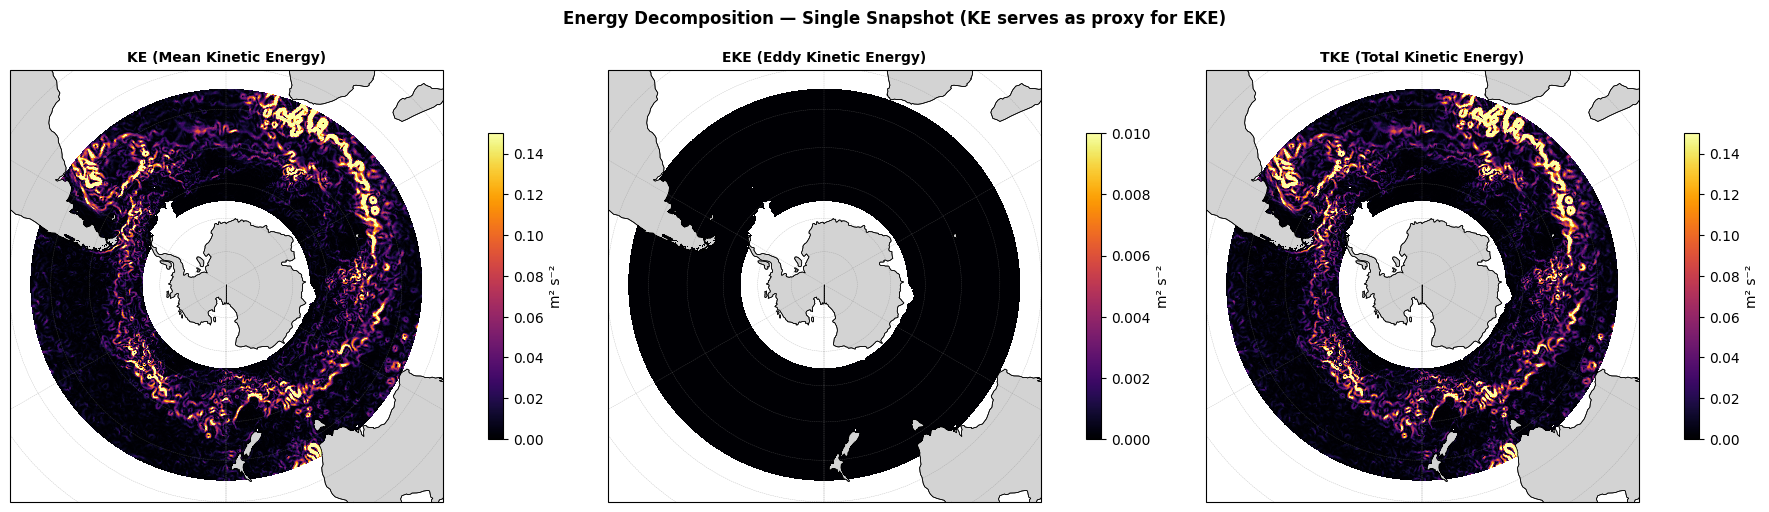

In [6]:
# ── Compute energy terms from sample data (single-snapshot proxy) ──
# For a single snapshot u' = 0, so EKE = 0. We demonstrate the formulas
# and show KE as a proxy. The full pipeline uses ~30 daily files per month
# to compute genuine within-month EKE = ½(var(u) + var(v)).
#
# Ice masking: preprocessing_region() applies a maximum ice mask —
# flag_ice.max(time) > 0 — so cells ice-covered on any day are fully excluded.
# For this single-snapshot test the per-timestep and max masks are identical.

if _sample_loaded:
    # In remote mode ds_sample is already the fetched xarray Dataset; in local
    # mode we re-open the test file so we have the raw (unprocessed) object.
    if USE_REMOTE_DATA:
        ds_test = ds_sample
    else:
        ds_test = xr.open_dataset(test_file)

    # Maximum ice mask applied inside preprocessing_region
    ds_test = preprocessing_region(ds_test, LONMIN, LONMAX, LATMIN, LATMAX)

    # --- KE (Mean Kinetic Energy) ---
    # Monthly-mean absolute geostrophic velocities
    u_mean = ds_test['ugos'].mean(dim='time', skipna=True)
    v_mean = ds_test['vgos'].mean(dim='time', skipna=True)
    ke = 0.5 * (u_mean**2 + v_mean**2)

    # --- EKE (Eddy Kinetic Energy) ---
    # Within-month variance of geostrophic velocities
    # EKE = ½(var(u_gos) + var(v_gos))
    # Here with a single timestep, var → 0; we compute nonetheless.
    eke = 0.5 * (ds_test['ugos'].var(dim='time', skipna=True)
               + ds_test['vgos'].var(dim='time', skipna=True))

    # --- TKE (Total Kinetic Energy) ---
    tke = ke + eke

    # Attach to processed dataset
    ds_test = ds_test.mean(dim='time')
    ds_test['ke']  = ke
    ds_test['eke'] = eke
    ds_test['tke'] = tke

    print("Energy term statistics (m² s⁻²):")
    print(f"  KE  — min: {float(ke.min()):.6f},  max: {float(ke.max()):.6f},  mean: {float(ke.mean()):.6f}")
    print(f"  EKE — min: {float(eke.min()):.6f},  max: {float(eke.max()):.6f},  mean: {float(eke.mean()):.6f}")
    print(f"  TKE — min: {float(tke.min()):.6f},  max: {float(tke.max()):.6f},  mean: {float(tke.mean()):.6f}")

    # ── Visualise KE, EKE, and TKE side by side ──
    fig, axes = plt.subplots(1, 3, figsize=(18, 5),
                             subplot_kw={'projection': ccrs.SouthPolarStereo()})
    titles = ['KE (Mean Kinetic Energy)', 'EKE (Eddy Kinetic Energy)', 'TKE (Total Kinetic Energy)']
    fields = [ke, eke, tke]
    vmaxs  = [0.15, 0.01, 0.15]  # EKE << KE for single snapshot

    for ax, field, title, vmax in zip(axes, fields, titles, vmaxs):
        ax.set_extent([-180, 180, -75, -30], crs=ccrs.PlateCarree())
        im = ax.pcolormesh(ds_test.longitude, ds_test.latitude, field,
                           transform=ccrs.PlateCarree(), cmap='inferno',
                           vmin=0, vmax=vmax)
        ax.add_feature(cfeature.LAND, facecolor='lightgray', edgecolor='k', linewidth=0.5)
        ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
        ax.gridlines(linewidth=0.3, color='gray', alpha=0.5, linestyle='--')
        plt.colorbar(im, ax=ax, label='m² s⁻²', shrink=0.7, pad=0.08)
        ax.set_title(title, fontsize=10, fontweight='bold')

    fig.suptitle('Energy Decomposition — Single Snapshot (KE serves as proxy for EKE)',
                 fontweight='bold', fontsize=12, y=1.02)
    plt.tight_layout()
    plt.show()


Longitude: 19.94°E — 1 envelope(s) detected
  Envelope 0: peak at -39.06°, half-power at -39.11°, width 361 km


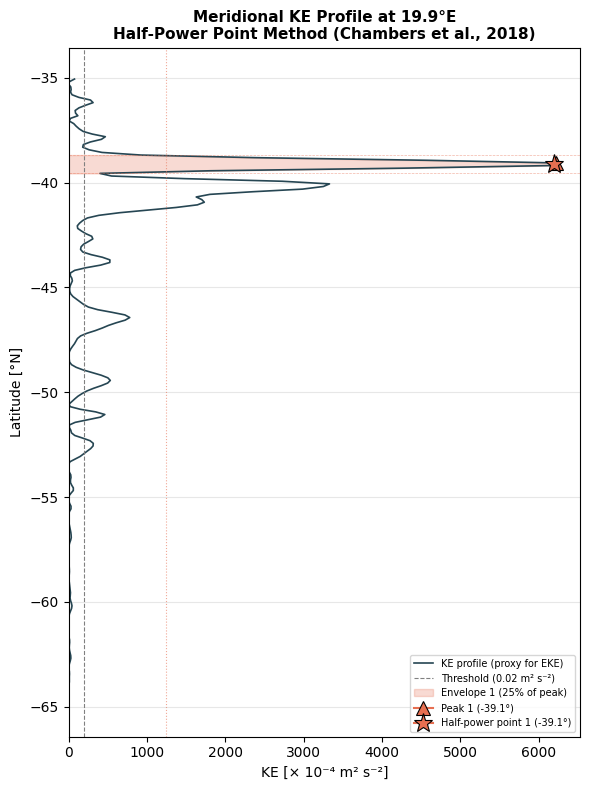

In [7]:
# ── Latitudinal profile: How the half-power point is chosen ──
# Pick a longitude where strong fronts exist (e.g. downstream of Drake Passage)
# and plot the meridional EKE profile, showing threshold, envelope, and half-power point.
#
# Since the sample has a single timestep (EKE ≈ 0), we use KE ('ke') as a
# proxy. The full pipeline applies this same procedure to genuine EKE fields.

from utils.chambers_fronts import detect_envelopes_on_profile, meridional_distances_km_from_lats

if _sample_loaded:
    # ── Choose an example longitude ──
    # We select a longitude with clear signal (e.g. 20°E — Agulhas Return Current)
    example_lon = 20.0
    j = int(np.argmin(np.abs(ds_test.longitude.values - example_lon)))
    actual_lon = float(ds_test.longitude.values[j])

    lats = ds_test.latitude.values
    profile = ds_test['ke'].values[:, j]  # use KE as proxy

    # Ensure south→north ordering
    if lats[0] > lats[-1]:
        lats = lats[::-1]
        profile = profile[::-1]

    lon_arr = np.full_like(lats, actual_lon, dtype=float)
    dists = meridional_distances_km_from_lats(lats)

    # ── Detect envelopes on this single profile ──
    envelopes = detect_envelopes_on_profile(
        profile, lats, lon_arr, dists=dists,
        threshold=THRESHOLD, min_width_km=MIN_WIDTH_KM,
        peak_fraction=PEAK_FRACTION, use_numba=False,
    )

    print(f"Longitude: {actual_lon:.2f}°E — {len(envelopes)} envelope(s) detected")
    for i, env in enumerate(envelopes):
        print(f"  Envelope {i}: peak at {env['peak_lat']:.2f}°, "
              f"half-power at {env['lat_mid']:.2f}°, "
              f"width {env['width_km']:.0f} km")

    # ── Plot ──
    fig, ax = plt.subplots(figsize=(6, 8))

    # Full meridional profile
    ax.plot(profile * 1e4, lats, color='#264653', linewidth=1.2, label='KE profile (proxy for EKE)')

    # Threshold
    ax.axvline(THRESHOLD * 1e4, color='gray', linestyle='--', linewidth=0.8,
               label=f'Threshold ({THRESHOLD} m² s⁻²)')

    # Colour each envelope
    colours = ['#e76f51', '#2a9d8f', '#e9c46a', '#f4a261']
    for i, env in enumerate(envelopes):
        c = colours[i % len(colours)]
        isouth, inorth = env['isouth'], env['inorth']

        # Shade envelope region
        ax.fill_betweenx(lats[isouth:inorth+1], 0, profile[isouth:inorth+1] * 1e4,
                         alpha=0.25, color=c, label=f'Envelope {i+1} (25% of peak)')

        # Peak
        ax.plot(env['peak_val'] * 1e4, env['peak_lat'], marker='^', markersize=10,
                color=c, markeredgecolor='k', markeredgewidth=0.8, zorder=6,
                label=f'Peak {i+1} ({env["peak_lat"]:.1f}°)')

        # 25% of peak line
        thresh_25 = env['peak_val'] * PEAK_FRACTION * 1e4
        ax.axvline(thresh_25, color=c, linestyle=':', linewidth=0.8, alpha=0.6)

        # Half-power point
        ax.plot(np.interp(env['lat_mid'], lats, profile) * 1e4, env['lat_mid'],
                marker='*', markersize=14, color=c, markeredgecolor='k',
                markeredgewidth=0.8, zorder=7,
                label=f'Half-power point {i+1} ({env["lat_mid"]:.1f}°)')

        # Envelope boundary lines
        ax.axhline(lats[isouth], color=c, linestyle='--', linewidth=0.5, alpha=0.5)
        ax.axhline(lats[inorth], color=c, linestyle='--', linewidth=0.5, alpha=0.5)

    ax.set_ylabel('Latitude [°N]')
    ax.set_xlabel('KE [× 10⁻⁴ m² s⁻²]')
    ax.set_title(f'Meridional KE Profile at {actual_lon:.1f}°E\n'
                 f'Half-Power Point Method (Chambers et al., 2018)',
                 fontweight='bold', fontsize=11)
    ax.legend(loc='lower right', fontsize=7, frameon=True, fancybox=True)
    ax.set_xlim(left=0)
    ax.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.show()


## 6. Full Pipeline: Process All Monthly Data

Loop over all yearly/monthly data, compute monthly-mean EKE (using the long-term
mean velocities and ice mask loaded from Notebook 0), detect fronts, and save
structured NetCDF files.

Each output file contains:
- The monthly-mean **EKE field** (2D: latitude × longitude)
- **Half-power point** positions (lon, lat)
- **Envelope boundaries** (25% of peak, south and north)
- **Peak EKE** value and latitude
- **Envelope width** in km

In [8]:
import calendar as _calendar

def process_month(year, month_name, output_dir,
                  u_ltm, v_ltm, ice_mask,
                  files_path=None):
    """Process one month of altimetry data: compute KE and EKE, detect fronts, save to NetCDF.

    Data source
    -----------
    When the global flag ``USE_REMOTE_DATA`` is True the month's daily data
    are streamed directly from the Copernicus Marine service using
    ``copernicusmarine.open_dataset()``. Otherwise ``files_path`` (a list of
    local .nc file paths) is read via ``xr.open_mfdataset()``.

    Quantities computed
    -------------------
    KE  = 1/2(ubar_month^2 + vbar_month^2)
          Mean Kinetic Energy from monthly-mean absolute geostrophic velocities.

    EKE = 1/2 * mean_t((u - ubar_lt)^2 + (v - vbar_lt)^2)
          Eddy Kinetic Energy from anomalies relative to the full study-period
          mean (u_ltm, v_ltm), averaged over the daily snapshots of this month.

    Ice masking:
        The permanent ice mask (computed once over the entire study period via
        compute_max_ice_mask) is passed in as `ice_mask` and applied here.
        A cell is NaN for the full month if it was ever ice-covered during the
        study period. This ensures the same spatial mask for every month and
        for the long-term mean used in the EKE anomalies.

    Front detection uses KE in this workflow.

    IMPORTANT: Front detection is performed ONCE per month on the monthly-mean
    KE field (2D lat×lon). We do NOT run half-power detection day-by-day.
    """

    if USE_REMOTE_DATA:
        # Remote data loading via Copernicus Marine Toolbox
        last_day = _calendar.monthrange(int(year), int(month_name))[1]
        ds = copernicusmarine.open_dataset(
            dataset_id=DATASET_ID,
            minimum_longitude=LONMIN,
            maximum_longitude=LONMAX,
            minimum_latitude=LATMIN,
            maximum_latitude=LATMAX,
            start_datetime=f"{year}-{month_name}-01",
            end_datetime=f"{year}-{month_name}-{last_day:02d}",
            variables=REMOTE_VARIABLES,
        )
    else:
        # Local data loading
        def _keep_needed(ds):
            return ds[['ugos', 'vgos', 'flag_ice']]

        ds = xr.open_mfdataset(
            files_path,
            combine='by_coords',
            preprocess=_keep_needed,
        )

    # Apply region selection + permanent study-period ice mask
    ds = preprocessing_region(ds, LONMIN, LONMAX, LATMIN, LATMAX,
                               ice_mask=ice_mask)

    # EKE from full-period anomalies
    # u'(t) = u(t) - ubar_lt; EKE = 1/2 * mean_t(u'^2 + v'^2)
    u_anom = ds['ugos'] - u_ltm
    v_anom = ds['vgos'] - v_ltm
    eke = 0.5 * (u_anom**2 + v_anom**2).mean(dim='time', skipna=True)

    # Monthly mean and KE
    ds_mean = ds.mean(dim='time')
    if 'time' in ds_mean.dims:
        raise RuntimeError(
            'Expected monthly-mean dataset without a time dimension; '
            'front detection must be monthly (2D).'
        )
    ke = 0.5 * (ds_mean['ugos']**2 + ds_mean['vgos']**2)

    ds_mean['ke'] = ke
    ds_mean['eke'] = eke
    ds_mean = ds_mean.load()

    # Run front detection ONCE for the month (2D KE field) in parallel across longitudes
    results = detect_fronts_from_dataset(
        ds_mean,
        eke_var='ke',
        use_numba=USE_NUMBA,
        sample_every=SAMPLE_EVERY,
        n_jobs=N_JOBS,
    )

    # Filter to valid latitude range
    filtered_results = {}
    for lon, envs in results.items():
        valid = [e for e in envs if LATMIN <= e['lat_mid'] <= LATMAX]
        if valid:
            filtered_results[lon] = valid

    n_fronts = sum(len(envs) for envs in filtered_results.values())

    if n_fronts == 0:
        print(f"  No fronts detected for {year}/{month_name}")
        return 0

    # Build arrays for NetCDF storage
    front_lons = np.zeros(n_fronts)
    front_lats = np.zeros(n_fronts)
    envelope_lat_south = np.zeros(n_fronts)
    envelope_lat_north = np.zeros(n_fronts)
    envelope_lon = np.zeros(n_fronts)
    peak_lat = np.zeros(n_fronts)
    peak_val = np.zeros(n_fronts)
    width_km = np.zeros(n_fronts)

    lat_vals = ds_mean.latitude.values

    idx = 0
    for lon, envs in filtered_results.items():
        for e in envs:
            front_lons[idx] = e['lon_mid']
            front_lats[idx] = e['lat_mid']
            envelope_lat_south[idx] = lat_vals[e['isouth']]
            envelope_lat_north[idx] = lat_vals[e['inorth']]
            envelope_lon[idx] = lon
            peak_lat[idx] = e['peak_lat']
            peak_val[idx] = e['peak_val']
            width_km[idx] = e['width_km']
            idx += 1

    # Create output Dataset
    ds_output = xr.Dataset(
        {
            'ke': (('latitude', 'longitude'), ds_mean['ke'].values),
            'eke': (('latitude', 'longitude'), ds_mean['eke'].values),
            'front_lon': (['front'], front_lons),
            'front_lat': (['front'], front_lats),
            'envelope_lon': (['front'], envelope_lon),
            'envelope_lat_south': (['front'], envelope_lat_south),
            'envelope_lat_north': (['front'], envelope_lat_north),
            'peak_lat': (['front'], peak_lat),
            'peak_val': (['front'], peak_val),
            'width_km': (['front'], width_km),
        },
        coords={
            'latitude': ds_mean.latitude.values,
            'longitude': ds_mean.longitude.values,
            'front': np.arange(n_fronts),
        },
        attrs={
            'title': 'Southern Ocean Fronts - Chambers (2018) Method',
            'description': 'Half-power points and 25% envelope boundaries',
            'method': 'Chambers, D. P. (2018)',
            'front_detection_field': 'ke',
            'data_source': f"{'copernicusmarine (remote): ' + DATASET_ID if USE_REMOTE_DATA else 'local files'}",
            'eke_reference': 'long-term mean over full study period',
            'ice_masking': 'permanent (max flag_ice over full study period)',
            'threshold': f'{THRESHOLD} m2/s2',
            'min_width': f'{MIN_WIDTH_KM} km',
            'peak_fraction': str(PEAK_FRACTION),
            'year': year,
            'month': month_name,
            'n_fronts_detected': n_fronts,
        }
    )

    ds_output['ke'].attrs = {
        'long_name': 'Mean Kinetic Energy',
        'units': 'm2/s2',
        'description': 'KE = 1/2(ubar^2 + vbar^2); monthly-mean absolute geostrophic velocities',
    }
    ds_output['eke'].attrs = {
        'long_name': 'Eddy Kinetic Energy',
        'units': 'm2/s2',
        'description': 'EKE = 1/2*mean_t((u-ubar_lt)^2+(v-vbar_lt)^2); anomalies from full-period mean',
    }
    ds_output['front_lon'].attrs = {'long_name': 'Half-power point longitude', 'units': 'degrees_east'}
    ds_output['front_lat'].attrs = {'long_name': 'Half-power point latitude', 'units': 'degrees_north'}
    ds_output['envelope_lon'].attrs = {'long_name': 'Envelope longitude', 'units': 'degrees_east'}
    ds_output['envelope_lat_south'].attrs = {'long_name': 'Southern boundary (25% of peak)', 'units': 'degrees_north'}
    ds_output['envelope_lat_north'].attrs = {'long_name': 'Northern boundary (25% of peak)', 'units': 'degrees_north'}
    ds_output['peak_lat'].attrs = {'long_name': 'Peak KE latitude', 'units': 'degrees_north'}
    ds_output['peak_val'].attrs = {'long_name': 'Peak KE value', 'units': 'm2/s2'}
    ds_output['width_km'].attrs = {'long_name': 'Envelope width', 'units': 'km'}

    year_dir = os.path.join(output_dir, year)
    os.makedirs(year_dir, exist_ok=True)
    outfile = os.path.join(year_dir, f"{month_name}.nc")
    ds_output.to_netcdf(outfile)
    print(f"  Saved {n_fronts} fronts -> {outfile}")
    return n_fronts

In [9]:
# ── Main processing loop ──────────────────────────────────────────────────────
total_fronts = 0
total_months = 0

for year in year_folders:
    if USE_REMOTE_DATA:
        # Remote: process all 12 calendar months; no filesystem scan needed
        months      = [f"{m:02d}" for m in range(1, 13)]
        files_lookup = None   # not used; remote branch in process_month
    else:
        # Local: discover available months from the directory tree
        year_path   = os.path.join(INPUT_DIR, year)
        month_dirs  = sorted([f for f in os.listdir(year_path)
                               if not f.startswith('.')])
        months      = month_dirs

    print(f"\n{'='*60}")
    print(f"Year {year} — {len(months)} months  "
          f"({'remote' if USE_REMOTE_DATA else 'local'})")
    print(f"{'='*60}")

    for month_name in months:
        if USE_REMOTE_DATA:
            files_path_month = None
            print(f"\nProcessing {year}/{month_name} (remote; daily snapshots → 1 monthly detection)…")
        else:
            month_path       = os.path.join(INPUT_DIR, year, month_name)
            files            = sorted([f for f in os.listdir(month_path)
                                       if f.endswith('.nc') and not f.startswith('.')])
            files_path_month = [os.path.join(month_path, f) for f in files]
            print(f"\nProcessing {year}/{month_name} ({len(files)} daily files → 1 monthly detection)…")

        n = process_month(
            year, month_name, OUTPUT_DIR,
            u_ltm=u_ltm, v_ltm=v_ltm, ice_mask=ice_mask,
            files_path=files_path_month,
        )
        total_fronts += n
        total_months += 1

print(f"\n{'='*60}")
print(f"COMPLETE: {total_fronts} fronts detected across {total_months} months")
print(f"Results saved to: {OUTPUT_DIR}")
print(f"{'='*60}")



Year 2001 — 12 months  (remote)

Processing 2001/01 (remote; daily snapshots → 1 monthly detection)…


INFO - 2026-07-06T07:16:28Z - Selected dataset version: "202411"
INFO - 2026-07-06T07:16:28Z - Selected dataset part: "default"


  Saved 3268 fronts -> outputs/monthly_half-power_points/2001/01.nc

Processing 2001/02 (remote; daily snapshots → 1 monthly detection)…


INFO - 2026-07-06T07:16:45Z - Selected dataset version: "202411"
INFO - 2026-07-06T07:16:45Z - Selected dataset part: "default"


  Saved 3535 fronts -> outputs/monthly_half-power_points/2001/02.nc

Processing 2001/03 (remote; daily snapshots → 1 monthly detection)…


...

  Saved 3471 fronts -> outputs/monthly_half-power_points/2025/10.nc

Processing 2025/11 (remote; daily snapshots → 1 monthly detection)…


INFO - 2026-07-06T08:48:02Z - Selected dataset version: "202411"
INFO - 2026-07-06T08:48:02Z - Selected dataset part: "default"


  Saved 3534 fronts -> outputs/monthly_half-power_points/2025/11.nc

Processing 2025/12 (remote; daily snapshots → 1 monthly detection)…


INFO - 2026-07-06T08:48:19Z - Selected dataset version: "202411"
INFO - 2026-07-06T08:48:19Z - Selected dataset part: "default"


  Saved 3541 fronts -> outputs/monthly_half-power_points/2025/12.nc

COMPLETE: 1027063 fronts detected across 300 months
Results saved to: outputs/monthly_half-power_points


## 7. Inspect Outputs

Load one of the monthly output NetCDF files and verify its structure.

Each file (e.g. `outputs/monthly_half-power_points/2010/03.nc`) contains:

| Variable | Dims | Description |
|---|---|---|
| `ke` | lat × lon | Monthly-mean Mean Kinetic Energy [m² s⁻²] |
| `eke` | lat × lon | Monthly-mean Eddy Kinetic Energy [m² s⁻²] |
| `front_lon` | front | Half-power point longitude [°E] |
| `front_lat` | front | Half-power point latitude [°N] |
| `envelope_lat_south` | front | Southern envelope boundary (25% of peak) [°N] |
| `envelope_lat_north` | front | Northern envelope boundary (25% of peak) [°N] |
| `peak_lat` | front | Latitude of peak EKE [°N] |
| `peak_val` | front | Peak EKE value [m² s⁻²] |
| `width_km` | front | Envelope width [km] |

Global attributes include the year, month, detection method, threshold, and ice-masking strategy.

In [10]:
# List available output files
from pathlib import Path

output_path = Path(OUTPUT_DIR)
output_years = sorted([y for y in output_path.iterdir() if y.is_dir() and y.name != '.DS_Store'])

print("Available outputs:")
for yp in output_years:
    months = sorted([m.name for m in yp.iterdir() if m.suffix == '.nc'])
    print(f"  {yp.name}: {months}")

Available outputs:
  2001: ['01.nc', '02.nc', '03.nc', '04.nc', '05.nc', '06.nc', '07.nc', '08.nc', '09.nc', '10.nc', '11.nc', '12.nc']
  2002: ['01.nc', '02.nc', '03.nc', '04.nc', '05.nc', '06.nc', '07.nc', '08.nc', '09.nc', '10.nc', '11.nc', '12.nc']
  2003: ['01.nc', '02.nc', '03.nc', '04.nc', '05.nc', '06.nc', '07.nc', '08.nc', '09.nc', '10.nc', '11.nc', '12.nc']
  2004: ['01.nc', '02.nc', '03.nc', '04.nc', '05.nc', '06.nc', '07.nc', '08.nc', '09.nc', '10.nc', '11.nc', '12.nc']
  2005: ['01.nc', '02.nc', '03.nc', '04.nc', '05.nc', '06.nc', '07.nc', '08.nc', '09.nc', '10.nc', '11.nc', '12.nc']
  2006: ['01.nc', '02.nc', '03.nc', '04.nc', '05.nc', '06.nc', '07.nc', '08.nc', '09.nc', '10.nc', '11.nc', '12.nc']
  2007: ['01.nc', '02.nc', '03.nc', '04.nc', '05.nc', '06.nc', '07.nc', '08.nc', '09.nc', '10.nc', '11.nc', '12.nc']
  2008: ['01.nc', '02.nc', '03.nc', '04.nc', '05.nc', '06.nc', '07.nc', '08.nc', '09.nc', '10.nc', '11.nc', '12.nc']
  2009: ['01.nc', '02.nc', '03.nc', '04.nc', 

In [11]:
# Load and inspect one output
if output_years:
    sample_file = sorted(output_years[-5].glob('*.nc'))[0]
    ds_out = xr.open_dataset(sample_file)
    print(f"File: {sample_file}")
    print(f"Attributes: {ds_out.attrs}")
    print(f"\nVariables:")
    for var in ds_out.data_vars:
        print(f"  {var}: {ds_out[var].dims} — {ds_out[var].attrs.get('long_name', '')}")
    
    print(f"\nSample fronts (first 5):")
    for i in range(min(5, len(ds_out.front))):
        print(f"  Front {i}: lon={float(ds_out.front_lon[i]):.1f}°, "
              f"lat={float(ds_out.front_lat[i]):.1f}°, "
              f"peak={float(ds_out.peak_val[i]):.4f} m²/s², "
              f"width={float(ds_out.width_km[i]):.0f} km")

File: outputs/monthly_half-power_points/2021/01.nc
Attributes: {'title': 'Southern Ocean Fronts - Chambers (2018) Method', 'description': 'Half-power points and 25% envelope boundaries', 'method': 'Chambers, D. P. (2018)', 'front_detection_field': 'ke', 'data_source': 'copernicusmarine (remote): cmems_obs-sl_glo_phy-ssh_my_allsat-l4-duacs-0.125deg_P1D', 'eke_reference': 'long-term mean over full study period', 'ice_masking': 'permanent (max flag_ice over full study period)', 'threshold': '0.02 m2/s2', 'min_width': '300.0 km', 'peak_fraction': '0.2', 'year': '2021', 'month': '01', 'n_fronts_detected': np.int64(3638)}

Variables:
  ke: ('latitude', 'longitude') — Mean Kinetic Energy
  eke: ('latitude', 'longitude') — Eddy Kinetic Energy
  front_lon: ('front',) — Half-power point longitude
  front_lat: ('front',) — Half-power point latitude
  envelope_lon: ('front',) — Envelope longitude
  envelope_lat_south: ('front',) — Southern boundary (25% of peak)
  envelope_lat_north: ('front',) — 

## 8. Visualise a Monthly Detection

Polar stereographic map of the **detected half-power points** (centres) and their **25% envelope boundaries** (error bars) for one output month. Each dot corresponds to one frontal zone identified by the half-power point method along a meridional EKE profile.

Use this to visually QC results: points should cluster near the ACC band (~50–60°S) and follow the known circumpolar front pattern.

Using monthly output: outputs/monthly_half-power_points/2001/01.nc
Frontal position error metrics:
  Median absolute deviation (MAD): 0.00 deg
  Standard deviation: 0.00 deg
  Median half-power to peak distance: 0.94 deg
  Interquartile range (IQR): 0.00 deg
Selected longitude: 90.00 deg
Found 1 envelopes at this section
All monthly half-power points: 3268
Half-power latitudes (deg): -49.01
Peak magnitudes (x1e-4 m2 s-2): 543
Saved: plots/front_detection/front_section_all_halfpower_with_seaice_KE_2001_01_p090p0.png
Saved: plots/front_detection/front_section_all_halfpower_with_seaice_KE_2001_01_p090p0.pdf


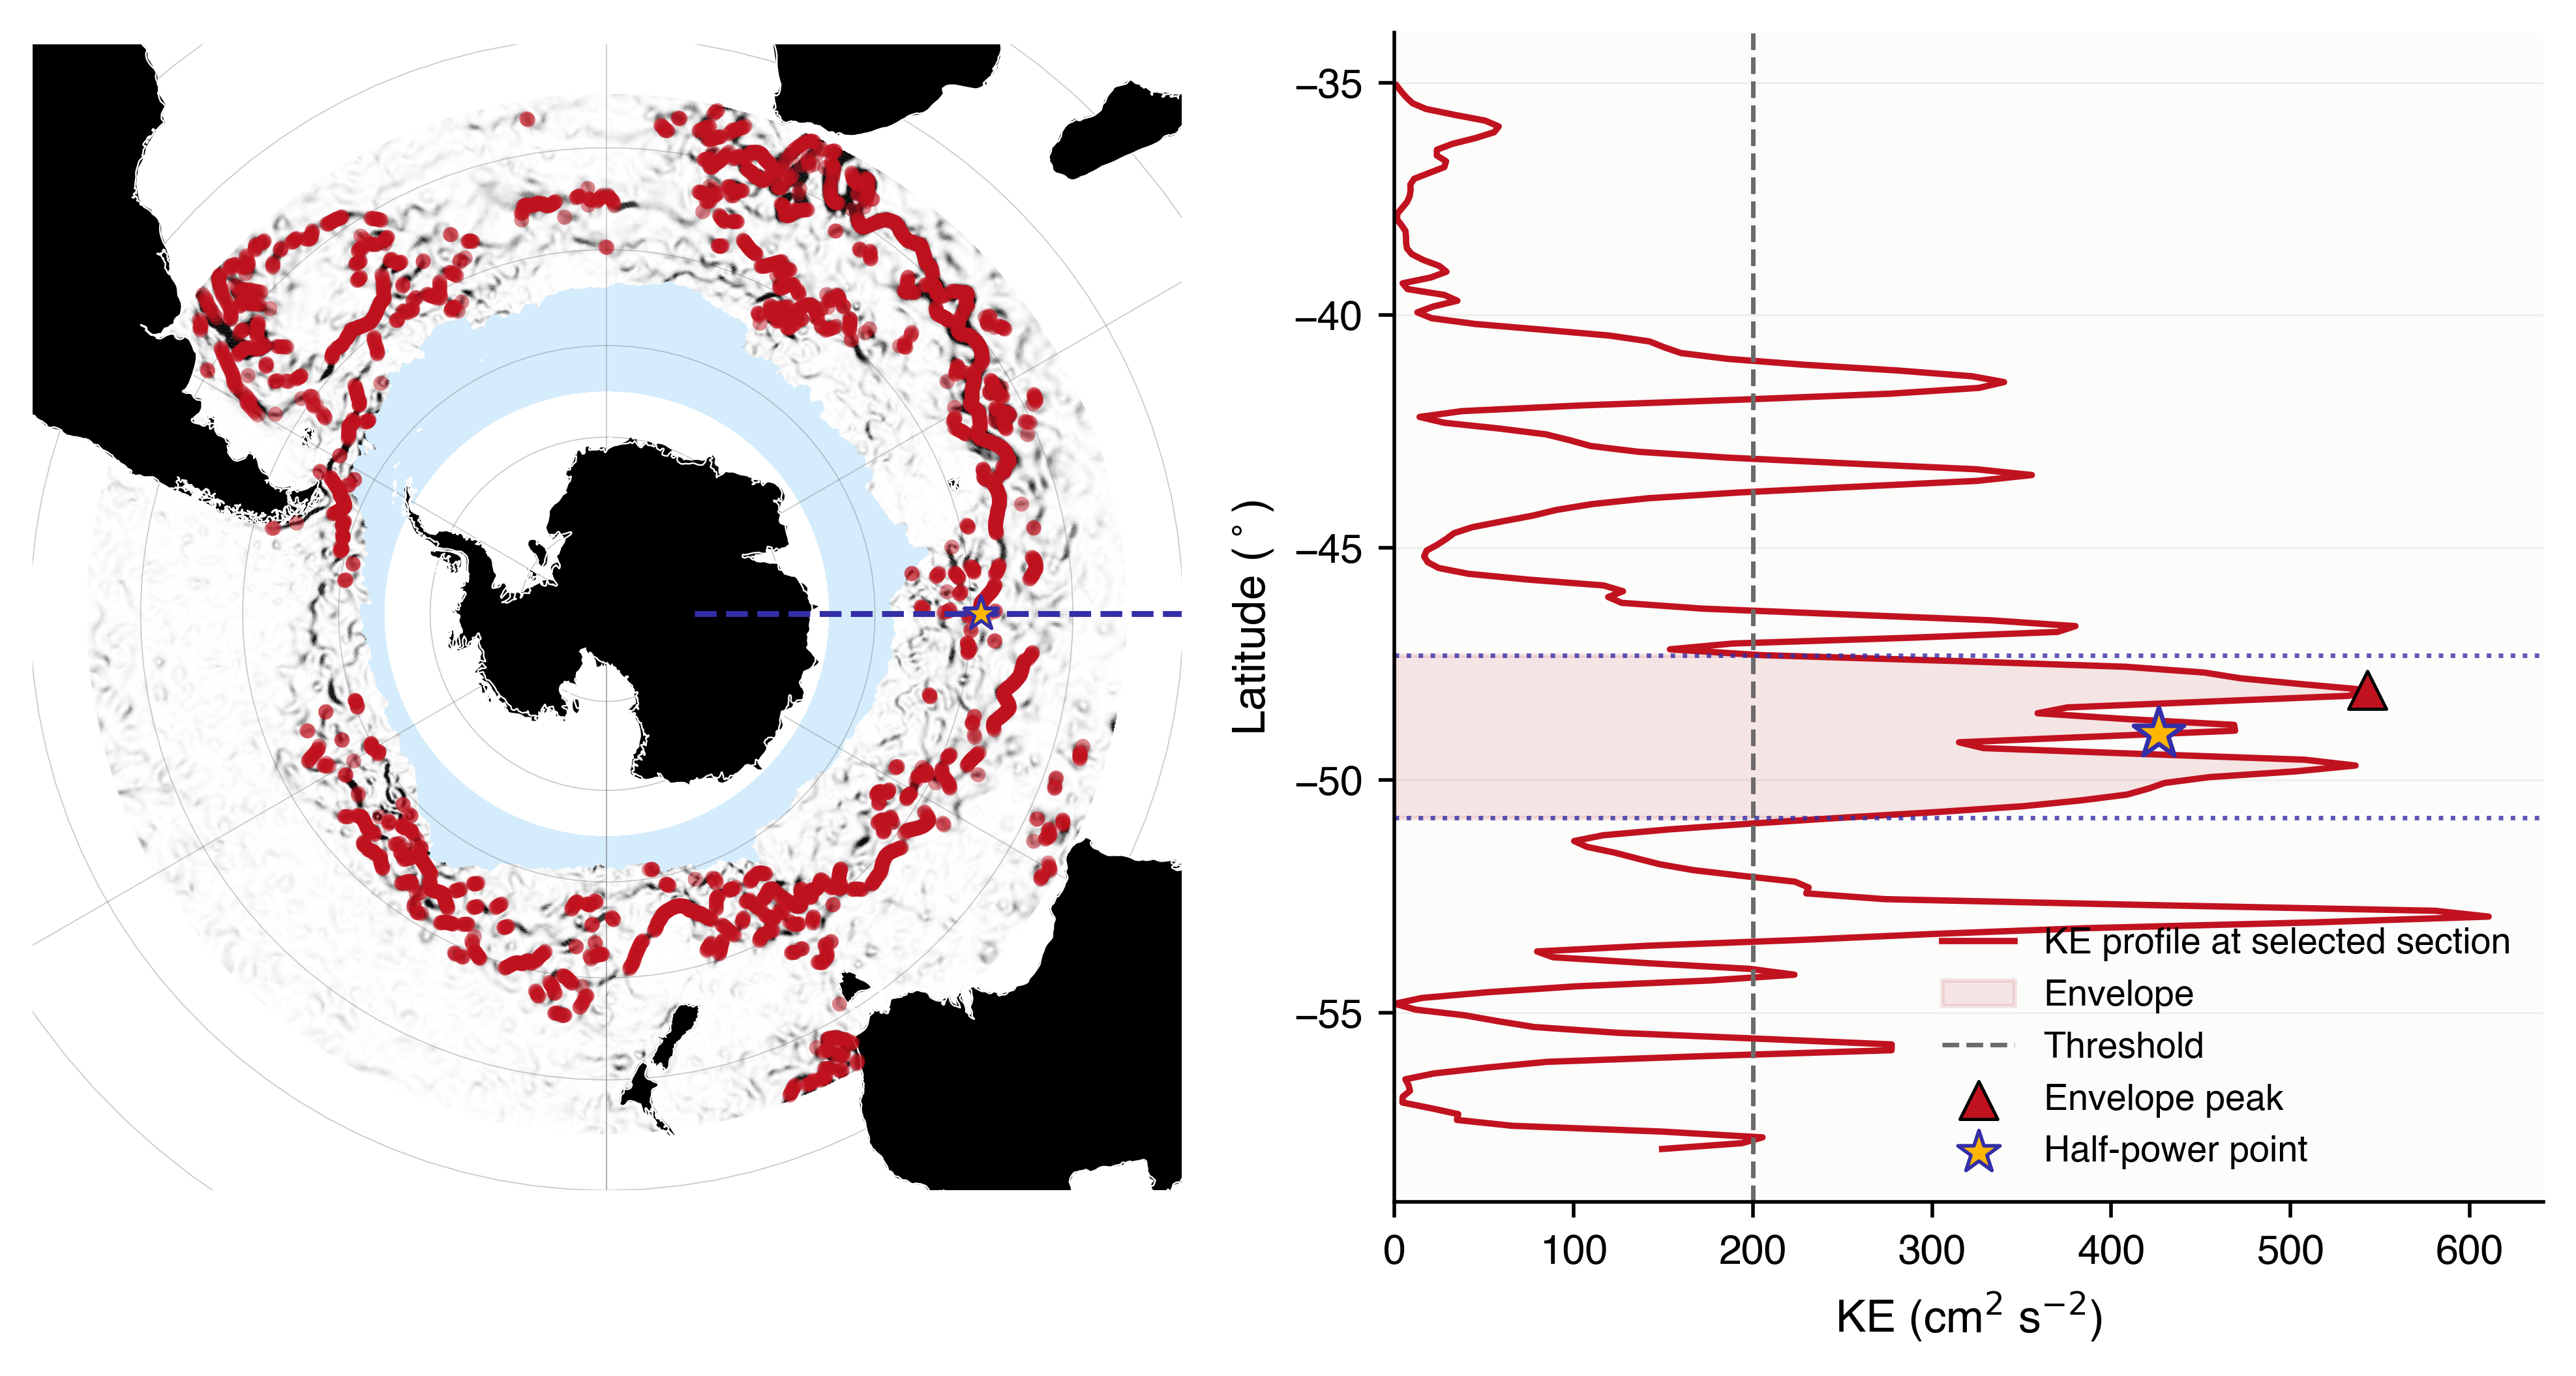

In [12]:
# Publication example: single-longitude profile and envelope error metrics (from MONTHLY output; KE-based)

from pathlib import Path
from utils.chambers_fronts import detect_envelopes_on_profile, meridional_distances_km_from_lats

# Style aligned with trend notebooks
STYLE = {
    'raw_alpha': 0.18,
    'raw_lw': 0.9,
    'smooth_lw': 1.9,
    'trend_lw': 1.4,
    'grid_alpha': 0.18,
    'grid_lw': 0.45,
    'axis_label_size': 10,
    'title_size': 10,
    'tick_size': 9,
    'annot_size': 8,
    'panel_size': 11,
    'neutral': '#7A8288',
    'series_lat': '#2F3E46',
    'series_wid': '#2A9D8F',
    'hp_color': '#FFB703',
    'peak_color': '#C1121F',
    'section_color': "#342EA7",
}

plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': ['Helvetica', 'Arial', 'DejaVu Sans'],
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.facecolor': '#FCFCFB',
    'figure.facecolor': 'white',
    'axes.titleweight': 'regular',
    'axes.labelsize': STYLE['axis_label_size'],
    'axes.titlesize': STYLE['title_size'],
    'xtick.labelsize': STYLE['tick_size'],
    'ytick.labelsize': STYLE['tick_size'],
    'figure.dpi': 150,
    'savefig.dpi': 300,
    'savefig.facecolor': 'white',
})

# --- Choose a monthly result file explicitly ---
EXAMPLE_YEAR = None   # e.g. "2001" (string) to force a specific year
EXAMPLE_MONTH = None  # e.g. "01" (string) to force a specific month

output_base = Path(OUTPUT_DIR)

if EXAMPLE_YEAR is not None and EXAMPLE_MONTH is not None:
    example_file = output_base / str(EXAMPLE_YEAR) / f"{int(EXAMPLE_MONTH):02d}.nc"
    if not example_file.exists():
        raise FileNotFoundError(f"Requested monthly output file not found: {example_file}")
else:
    nc_files = sorted(output_base.glob('*/*.nc'))
    if len(nc_files) == 0:
        raise FileNotFoundError(f'No monthly output files found under {output_base}')
    example_file = nc_files[0]

ds_out = xr.open_dataset(example_file)
print(f"Using monthly output: {example_file}")

# Basic sanity checks: this must be a monthly (2D) product
if 'ke' not in ds_out:
    raise KeyError('This example requires the ke variable in the monthly output file.')
if 'time' in ds_out['ke'].dims:
    raise RuntimeError('Expected monthly output with 2D ke (latitude×longitude), but ke still has a time dimension.')
required_front_vars = ['front_lon', 'front_lat']
for v in required_front_vars:
    if v not in ds_out:
        raise KeyError(f"Monthly output is missing required variable: {v}")

front_lon = ds_out['front_lon'].values
front_lat = ds_out['front_lat'].values
lon_vals = ds_out.longitude.values
lat_vals = ds_out.latitude.values

# Use longitude section 35 only
selected_lon =90.0
j_selected = int(np.argmin(np.abs(lon_vals - selected_lon)))
profile = ds_out['ke'].values[:, j_selected]
lats = lat_vals.copy()

# Ensure south-to-north order for robust profile integration
if lats[0] > lats[-1]:
    lats = lats[::-1]
    profile = profile[::-1]

lon_arr = np.full_like(lats, selected_lon, dtype=float)
dists = meridional_distances_km_from_lats(lats)

envelopes = detect_envelopes_on_profile(
    profile,
    lats,
    lon_arr,
    dists=dists,
    threshold=THRESHOLD,
    min_width_km=MIN_WIDTH_KM,
    peak_fraction=PEAK_FRACTION,
    use_numba=False,
    )

if len(envelopes) == 0:
    raise RuntimeError(f'No envelope detected at longitude {selected_lon} in this month.')

# Sort envelopes by strength and extract all half-power points for this section
envs = sorted(envelopes, key=lambda e: e['peak_val'], reverse=True)
lat_mids = np.array([float(e['lat_mid']) for e in envs], dtype=float)
lat_s_all = np.array([float(lats[e['isouth']]) for e in envs], dtype=float)
lat_n_all = np.array([float(lats[e['inorth']]) for e in envs], dtype=float)
peak_lats_all = np.array([float(e['peak_lat']) for e in envs], dtype=float)
peak_vals_all = np.array([float(e['peak_val']) for e in envs], dtype=float)

# Keep strongest envelope only for a subtle reference in the profile
env = envs[0]
lat_mid = float(env['lat_mid'])
lat_s = float(lats[env['isouth']])
lat_n = float(lats[env['inorth']])
peak_lat = float(env['peak_lat'])
peak_val = float(env['peak_val'])

# Error metrics for frontal position using all half-power points in the section
mad_lat = np.median(np.abs(lat_mids - np.median(lat_mids)))
std_lat = np.std(lat_mids)
mad_hp_peak = np.median(np.abs(lat_mids - peak_lats_all))
iqr_lat = np.percentile(lat_mids, 75) - np.percentile(lat_mids, 25)

print('Frontal position error metrics:')
print(f'  Median absolute deviation (MAD): {mad_lat:.2f} deg')
print(f'  Standard deviation: {std_lat:.2f} deg')
print(f'  Median half-power to peak distance: {mad_hp_peak:.2f} deg')
print(f'  Interquartile range (IQR): {iqr_lat:.2f} deg')

# Figure layout
fig = plt.figure(figsize=(8,4.5), dpi=500)
ax_map = fig.add_subplot(1, 2, 1, projection=ccrs.SouthPolarStereo())
ax_prof = fig.add_subplot(1, 2, 2)

# Left panel: map with all monthly half-power points + selected section
ax_map.set_extent([-180, 180, -80, -30], crs=ccrs.PlateCarree())
ax_map.set_frame_on(False)

# Background KE
ax_map.pcolormesh(
    ds_out.longitude.values,
    ds_out.latitude.values,
    ds_out['ke'].values,
    transform=ccrs.PlateCarree(),
    cmap='Greys',
    vmin=0,
    vmax=np.nanpercentile(ds_out['ke'].values, 95),
    alpha=0.78,
    shading='auto',
    zorder=1,
    rasterized=True,
 )

# Permanent sea-ice mask from Notebook 0 outputs (if available in kernel)
if 'ice_mask' in globals():
    try:
        ice_vals = ice_mask.values.astype(float)
        ice_plot = np.where(ice_vals > 0, 1.0, np.nan)
        ax_map.contourf(
            ice_mask.longitude.values,
            ice_mask.latitude.values,
            ice_plot,
            levels=[0.5, 1.5],
            colors=['#88C9F9'],
            alpha=0.35,
            transform=ccrs.PlateCarree(),
            zorder=2,
        )
    except Exception as exc:
        print(f'Warning: could not overlay sea-ice mask ({exc})')

# Black continents + coastlines
ax_map.add_feature(cfeature.LAND, facecolor='black', edgecolor='black', linewidth=0.2, zorder=5)
ax_map.coastlines(resolution='50m', linewidth=0.35, color='white', zorder=6)

# All monthly half-power points (all detected fronts in the month)
ax_map.scatter(
    front_lon,
    front_lat,
    s=11,
    c=STYLE['peak_color'],
    edgecolors='none',
    alpha=0.48,
    transform=ccrs.PlateCarree(),
    zorder=7,
    rasterized=True,
 )

# Selected section meridian
ax_map.plot(
    np.full(600, selected_lon),
    np.linspace(-80, -30, 600),
    transform=ccrs.PlateCarree(),
    color=STYLE['section_color'],
    linewidth=1.3,
    linestyle='--',
    zorder=8,
 )

# All envelope ranges + all half-power points at the selected section
for ls, ln in zip(lat_s_all, lat_n_all):
    ax_map.plot(
        [selected_lon, selected_lon],
        [ls, ln],
        transform=ccrs.PlateCarree(),
        color=STYLE['section_color'],
        linewidth=1.1,
        alpha=0.68,
        zorder=9,
    )
ax_map.scatter(
    np.full_like(lat_mids, selected_lon),
    lat_mids,
    transform=ccrs.PlateCarree(),
    s=62,
    marker='*',
    c=STYLE['hp_color'],
    edgecolors=STYLE['section_color'],
    linewidths=0.75,
    zorder=10,
 )

ax_map.gridlines(draw_labels=False, linewidth=0.25, color='#666666', alpha=0.35)

# Right panel: KE profile at selected section with all envelopes/half-power points
prof_scale = 1e4
ax_prof.plot(
    profile * prof_scale,
    lats,
    color=STYLE['peak_color'],
    linewidth=1.4,
    label='KE profile at selected section',
)

# Shade all detected envelopes
for idx, e in enumerate(envs):
    i0 = int(e['isouth'])
    i1 = int(e['inorth']) + 1
    ax_prof.fill_betweenx(
        lats[i0:i1],
        0,
        profile[i0:i1] * prof_scale,
        color=STYLE['peak_color'],
        alpha=0.10,
        label='Envelope' if idx == 0 else None,
    )

ax_prof.axvline(
    THRESHOLD * prof_scale,
    color='#6B6B6B',
    linestyle='--',
    linewidth=1.0,
    label=f'Threshold',
)

# All envelope peaks
ax_prof.scatter(
    peak_vals_all * prof_scale,
    peak_lats_all,
    marker='^',
    s=70,
    c=STYLE['peak_color'],
    edgecolors='black',
    linewidths=0.7,
    zorder=8,
    label='Envelope peak',
)

# All half-power points
hp_x = np.interp(lat_mids, lats, profile) * prof_scale
ax_prof.scatter(
    hp_x,
    lat_mids,
    marker='*',
    s=95,
    c=STYLE['hp_color'],
    edgecolors=STYLE['section_color'],
    linewidths=0.8,
    zorder=9,
    label='Half-power point',
)

# Strongest envelope reference lines
ax_prof.axhline(lat_s, color=STYLE['section_color'], linestyle=':', linewidth=1.0, alpha=0.8)
ax_prof.axhline(lat_n, color=STYLE['section_color'], linestyle=':', linewidth=1.0, alpha=0.8)
ax_prof.scatter(
    [np.interp(lat_mid, lats, profile) * prof_scale],
    [lat_mid],
    marker='*',
    s=135,
    c=STYLE['hp_color'],
    edgecolors=STYLE['section_color'],
    linewidths=1.0,
    zorder=11,
 )

ax_prof.set_xlabel(r'KE (cm$^2$ s$^{-2}$)')
ax_prof.set_ylabel(r'Latitude ($^\circ$)')
ax_prof.grid(axis='y', alpha=STYLE['grid_alpha'], lw=STYLE['grid_lw'])
ax_prof.legend(frameon=False, fontsize=8, loc='lower right')
ax_prof.set_xlim(left=0)

year_str = ds_out.attrs.get('year', '?')
month_str = ds_out.attrs.get('month', '?')
plt.tight_layout(rect=[0, 0, 1, 0.96])

# Save publication-ready figure
save_dir = Path(REPO_ROOT) / 'plots' / 'front_detection'
save_dir.mkdir(parents=True, exist_ok=True)
lon_tag = f'{selected_lon:+06.1f}'.replace('+', 'p').replace('-', 'm').replace('.', 'p')
out_png = save_dir / f'front_section_all_halfpower_with_seaice_KE_{year_str}_{month_str}_{lon_tag}.png'
out_pdf = save_dir / f'front_section_all_halfpower_with_seaice_KE_{year_str}_{month_str}_{lon_tag}.pdf'
fig.savefig(out_png, dpi=300, bbox_inches='tight')
fig.savefig(out_pdf, dpi=300, bbox_inches='tight')

hp_preview = ', '.join([f"{x:.2f}" for x in lat_mids[:10]])
if lat_mids.size > 10:
    hp_preview += ', ...'
peak_preview = ', '.join([f"{x * prof_scale:.0f}" for x in peak_vals_all[:10]])
if peak_vals_all.size > 10:
    peak_preview += ', ...'

print(f'Selected longitude: {selected_lon:.2f} deg')
print(f'Found {len(envs)} envelopes at this section')
print(f'All monthly half-power points: {len(front_lon)}')
print(f'Half-power latitudes (deg): {hp_preview}')
print(f'Peak magnitudes (x1e-4 m2 s-2): {peak_preview}')
print(f'Saved: {out_png}')

# Publication copy: manuscript figure 'front_trends', panels a-b
# (the article uses the 2001-01 example at the default section longitude)
fig_dir = Path(REPO_ROOT) / 'figures' / 'manuscript'
fig_dir.mkdir(parents=True, exist_ok=True)
fig.savefig(fig_dir / 'front_trends_detection_example.png', dpi=300, bbox_inches='tight')
print(f"Saved: {fig_dir / 'front_trends_detection_example.png'}")
print(f'Saved: {out_pdf}')

plt.show()